In [22]:
import joblib

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns

In [ ]:
mc_dir = "/pool1/lhcb/zhicaiz/mc/2024/HNL_Wmumuqq/ntuple/ntuple_20260228/"
data_dir = "/pool1/lhcb/zhicaiz/data/Collision24/ntuple_HNL_Wmumuqq/"
mc_file = "42912041_50GeVCtau1000ps_options_20260228_111712_skim.root"
data_file = "data_MagUp_Sprucing24r1_all_disk_options_20260228_011229_skim.root"

mc_path = os.path.join(mc_dir, mc_file)
data_path = os.path.join(data_dir, data_file)
direction = "myTupleOS1J"

branch_file = "./csv/branches_to_train.csv"
branches_to_load = pd.read_csv(branch_file)["Branch"].tolist()

print("Branches to load:", branches_to_load)

Branches to load: ['Mu_POSITION_STATEAT_LastMeasurement_Z', 'Mu_PT', 'Mu_HCALEOP', 'Mu_ELECTRONSHOWEREOP', 'Mu_BREMTRACKBASEDENERGY', 'Mu_PROBNN_PI', 'Mu_PROBNN_GHOST', 'Mu_PROBNN_MU', 'MuNuR_OWNPVIP', 'MuNuR_MINIP', 'MuNuR_POSITION_STATEAT_LastMeasurement_Z', 'MuNuR_E', 'MuNuR_P', 'MuNuR_PZ', 'nTTracks', 'nFTClusters']


In [24]:
def load_root(root_file, branches, direction = "myTupleOS1J", type="mc"):
    """
    从 ROOT 文件加载数据到 pandas DataFrame。
    MC 文件标记为 1,真实数据标记为 0。

    参数：
    - root_file: ROOT 文件的路径。
    - branches: 要加载的分支名列表。
    - direction: ROOT 文件中树的路径（默认是 "myTupleOS1J"）。
    - type: "mc" 表示蒙特卡洛数据，"data" 表示真实数据（默认是 "mc"）。

    返回：
    - 一个包含加载数据并附加 "label" 列的 pandas DataFrame。
    """
    with uproot.open(root_file) as f:
        treepath = f"{direction}/DecayTree"
        tree = f[treepath]
        df = tree.arrays(branches, library="pd")
        df = df.fillna(0)
        df["label"] = 1 if type == "mc" else 0
    return df

In [ ]:
# Load all MC files containing "_skim" in mc_dir
mc_dfs = []
for file_name in os.listdir(mc_dir):
    if "_skim" in file_name:
        full_path = os.path.join(mc_dir, file_name)
        try:
            df = load_root(full_path, branches_to_load, direction, type="mc")
            # print(f"shape {df.shape}")
            mc_dfs.append(df)
        except Exception as e:
            print(f"Error loading {file_name}: {e}")

print(len(mc_dfs), "MC files loaded successfully.")
if mc_dfs:
    mc_set = pd.concat(mc_dfs, ignore_index=True)
else:
    print("No MC files found matching criteria.")
    mc_set = pd.DataFrame()

# Load Data file
data_set = load_root(data_path, branches_to_load, direction, type="data")

print("MC data shape:", mc_set.shape)
print("Data data shape:", data_set.shape)

total_data = pd.concat([mc_set, data_set], ignore_index=True)
print("Total data shape:", total_data.shape)

X = total_data.drop(columns=["label"])
y = total_data["label"]
print("Feature data shape:", X.shape)
print("Label data shape:", y.shape)

In [ ]:
gbdt = joblib.load("gbdt_model.pkl")

In [ ]:
y_pred = gbdt.predict(X)
y_proba = gbdt.predict_proba(X) if hasattr(gbdt, 'predict_proba') else None

print('Accuracy:', accuracy_score(y, y_pred))
print(classification_report(y, y_pred))
cm = confusion_matrix(y, y_pred)
print('Confusion matrix:\n', cm)

Accuracy: 0.9985758648653994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     35668
           1       1.00      1.00      1.00     14889

    accuracy                           1.00     50557
   macro avg       1.00      1.00      1.00     50557
weighted avg       1.00      1.00      1.00     50557

Confusion matrix:
 [[35668     0]
 [   72 14817]]


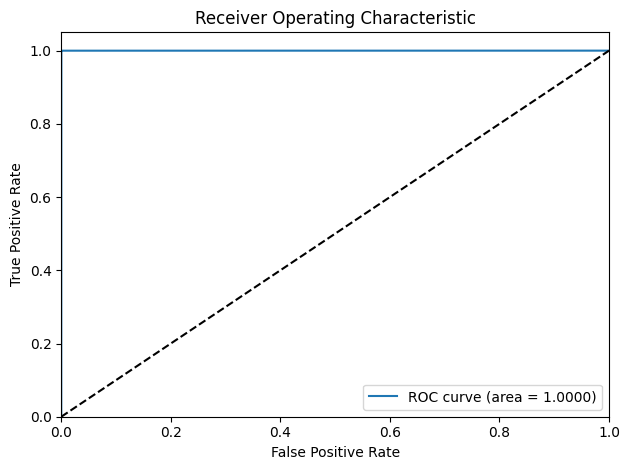

In [ ]:
## 绘制roc曲线（可选）
from sklearn.metrics import roc_curve, auc
if y_proba is not None:
    fpr, tpr, thresholds = roc_curve(y, y_proba[:, 1])
    roc_auc = auc(fpr, tpr)
    # plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()